# WORLD CUP 2026 LIVE WIN-PROBABILITY ENGINE
**Developer Workspace** This notebook ingests historical international football results, standardizes economic squad values, trains a Predicitve Neural Network to output symmetric match baselines, and spins up an interactive live-match Bayesian tracking matrix.

In [50]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import time

pd.options.display.float_format = '{:,.2f}'.format
sns.set_theme(style="whitegrid")

print("Setup done!")

df_matches = pd.read_csv('all_matches.csv')
df_matches['date'] = pd.to_datetime(df_matches['date'])

def determine_outcome(row):
    if row['home_score'] > row['away_score']: return 'H'
    if row['home_score'] < row['away_score']: return 'A'
    return 'D'
df_matches['outcome'] = df_matches.apply(determine_outcome, axis=1)
df_modern = df_matches[df_matches['date'] >= '2000-01-01'].copy()
df_modern['target_binary'] = np.where(df_modern['home_score'] > df_modern['away_score'], 1, np.where(df_modern['home_score'] < df_modern['away_score'], 0, np.nan))

df_modern['target_draw'] = np.where(df_modern['home_score'] == df_modern['away_score'], 1, 0)

def assign_match_wt(t):
    t = str(t).lower()
    if 'world cup' in t and 'qual' not in t: return 4
    if any(x in t for x in ['euro', 'copa america', 'african cup', 'afcon']) and 'qual' not in t: return 3
    if 'qual' in t or 'nations league' in t: return 2
    return 1
df_modern['match_wt'] = df_modern['tournament'].apply(assign_match_wt)
def compute_elo(df, k=20, int_rat=1500):
    df = df.sort_values('date').copy()
    teams = set(df['home_team']).union(set(df['away_team']))
    elo = {team: int_rat for team in teams}

    home_elo = []
    away_elo = []

    for _, row in df.iterrows():
        home = row['home_team']
        away = row['away_team']

        h_rat = elo[home]
        a_rat = elo[away]

        home_elo.append(h_rat)
        away_elo.append(a_rat)

        exp_home = 1 / (1 + 10 ** ((a_rat - h_rat) / 400))
        exp_away = 1 - exp_home

        if row['home_score'] > row['away_score']:
            act_h, act_a = 1, 0
        elif row['home_score'] < row['away_score']:
            act_h, act_a = 0, 1
        else:
            act_h, act_a = .5, .5
        
        elo[home] = h_rat + k * (act_h - exp_home)
        elo[away] = a_rat + k * (act_a - exp_away)

    df['home_elo'] = home_elo
    df['away_elo'] = away_elo
    df['elo_diff'] = df['home_elo'] - df['away_elo']

    return df, elo
    
df_modern, elo_dict = compute_elo(df_modern)
print(f"Loaded {df_modern.shape} matches from the modern era.") 
df_modern.sample(5)



Setup done!
Loaded (25450, 15) matches from the modern era.


,date,home_team,away_team,home_score,away_score,tournament,country,neutral,outcome,target_binary,target_draw,match_wt,home_elo,away_elo,elo_diff
49920,2024-10-14,Aruba,Haiti,3,5,CONCACAF Nations League B,Aruba,False,A,0.00,0,2,"1,326.46","1,594.64",-268.18
38096,2012-07-07,British Virgin Islands,Anguilla,1,0,Friendly,British Virgin Islands,False,H,1.00,0,1,"1,350.59","1,337.65",12.94
43868,2018-10-04,Palestine,Tajikistan,2,0,Bangabandhu Gold Cup,Bangladesh,True,H,1.00,0,1,"1,497.32","1,460.92",36.41
34772,2009-01-05,Rwanda,Somalia,3,0,CECAFA Cup,Uganda,True,H,1.00,0,1,"1,500.59","1,328.47",172.11
48092,2023-03-28,Turkey,Croatia,0,2,European Championship qual,Turkey,False,A,0.00,0,2,"1,663.83","1,779.68",-115.85


In [51]:
print("Connection to internation data archive for rolling stats started!")
try:
    url = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"
    df_raw = pd.read_csv(url)
    df_raw['date'] = pd.to_datetime(df_raw['date'])
    df_recent = df_raw[df_raw['date'] >= '2021-01-01'].copy()
    print(f"Successfully created {df_recent.shape[0]} live metrics from recent cycles.")
except Exception as e:
    print(f"Failed: {e}")
    df_recent = df_modern[df_modern['date'] >= '2021-01-01'].copy()

home_stats = df_recent.groupby('home_team').agg(
    MP=('home_score', 'count'), GF=('home_score', 'sum'), GA=('away_score', 'sum'),
    W=('home_score', lambda x: (x > df_recent.loc[x.index, 'away_score']).sum()),
    D=('home_score', lambda x: (x == df_recent.loc[x.index, 'away_score']).sum()),
    L=('home_score', lambda x: (x < df_recent.loc[x.index, 'away_score']).sum())
)

away_stats = df_recent.groupby('away_team').agg(
    MP=('away_score', 'count'), GF=('away_score', 'sum'), GA=('home_score', 'sum'),
    W=('away_score', lambda x: (x > df_recent.loc[x.index, 'home_score']).sum()),
    D=('away_score', lambda x: (x == df_recent.loc[x.index, 'home_score']).sum()),
    L=('away_score', lambda x: (x < df_recent.loc[x.index, 'home_score']).sum())
)

df_global_live = home_stats.add(away_stats, fill_value=0).reset_index().rename(columns={'index': 'Squad'})
df_global_live['goals_scored_per_game'] = df_global_live['GF'] / df_global_live['MP']
df_global_live['goals_conceded_per_game'] = df_global_live['GA'] / df_global_live['MP']
df_global_live['win_ratio'] = df_global_live['W'] / df_global_live['MP']
df_global_live.to_csv('global_teams_profiles.csv', index=False)
print(f"Created baseline for {df_global_live.shape[0]} international squads")
df_global_live.sample(5)

Connection to internation data archive for rolling stats started!
Successfully created 5755 live metrics from recent cycles.
Created baseline for 262 international squads


,Squad,MP,GF,GA,W,D,L,goals_scored_per_game,goals_conceded_per_game,win_ratio
93,Guatemala,76.00,104.00,91.00,30.00,20.00,26.00,1.37,1.20,0.39
192,Saint Lucia,29.00,37.00,52.00,13.00,3.00,13.00,1.28,1.79,0.45
241,Uganda,53.00,51.00,66.00,18.00,11.00,24.00,0.96,1.25,0.34
96,Guinea-Bissau,46.00,45.00,65.00,11.00,13.00,22.00,0.98,1.41,0.24
61,Dominica,30.00,34.00,52.00,8.00,8.00,14.00,1.13,1.73,0.27


In [52]:
df_custom_wc = pd.read_csv('world_cup_teams.csv')
def convertor(val):
    if pd.isna(val):
        return 0.0

    val = str(val).upper().replace('€', '').strip()

    if val.endswith('BN'):
        return float(val[:-2]) * 1_000_000_000

    if val.endswith('B'):
        return float(val[:-1]) * 1_000_000_000

    if val.endswith('M'):
        return float(val[:-1]) * 1_000_000
    
    if val.endswith('K'):
        return float(val[:-1]) * 1_000

    return float(val)
df_custom_wc['market_value_euros'] = df_custom_wc['market_value_euros'].apply(convertor)
df_custom_wc['average_market_value_euros'] = df_custom_wc['average_market_value_euros'].apply(convertor)
df_master_profiles = pd.merge(df_custom_wc, df_global_live[['Squad', 'goals_scored_per_game', 'goals_conceded_per_game', 'win_ratio']], left_on='club', right_on='Squad', how='inner').drop(columns=['Squad']).rename(columns={'club':  'Squad'})
df_wc_matches = df_modern[df_modern['home_team'].isin(df_master_profiles['Squad']) | df_modern['away_team'].isin(df_master_profiles['Squad'])].copy()

df_final_features = pd.merge(df_wc_matches, df_master_profiles.add_prefix('home_'), left_on='home_team', right_on='home_Squad', how='left').drop(columns=['home_Squad'])
df_final_features = pd.merge(df_final_features, df_master_profiles.add_prefix('away_'), left_on='away_team', right_on='away_Squad', how='left').drop(columns=['away_Squad'])

df_final_features['home_host_indicator'] = ((df_final_features['country'] == df_final_features['home_team']) & (df_final_features['neutral'] == False)).astype(float)
df_final_features['away_host_indicator'] = ((df_final_features['country'] == df_final_features['away_team']) & (df_final_features['neutral'] == False)).astype(float)

fill_baselines = {
    'home_fifa_ranking': df_master_profiles['fifa_ranking'].median(), 'home_average_age': 26.5, 'home_historical_participation': 1.0,
    'home_market_value_euros': 15000000.0, 'home_average_market_value_euros': 600000.0, 'home_squad_size': 25.0,
    'home_fifa_points': df_master_profiles['fifa_points'].median(), 'home_goals_scored_per_game': 1.0, 'home_goals_conceded_per_game': 1.5, 'home_win_ratio': df_master_profiles['win_ratio'].median(),
    'away_fifa_ranking': df_master_profiles['fifa_ranking'].median(), 'away_average_age': 26.5, 'away_historical_participation': 1.0,
    'away_market_value_euros': 15000000.0, 'away_average_market_value_euros': 600000.0, 'away_squad_size': 25.0,
    'away_fifa_points': df_master_profiles['fifa_points'].median(), 'away_goals_scored_per_game': 1.0, 'away_goals_conceded_per_game': 1.5, 'away_win_ratio': df_master_profiles['win_ratio'].median()
}
df_final_features = df_final_features.fillna(value=fill_baselines)
df_final_features['neutral_flag'] = df_final_features['neutral'].astype(int).astype('float32')
print(f"Feature Array Shape: {df_final_features.shape[0]}")



Feature Array Shape: 12061


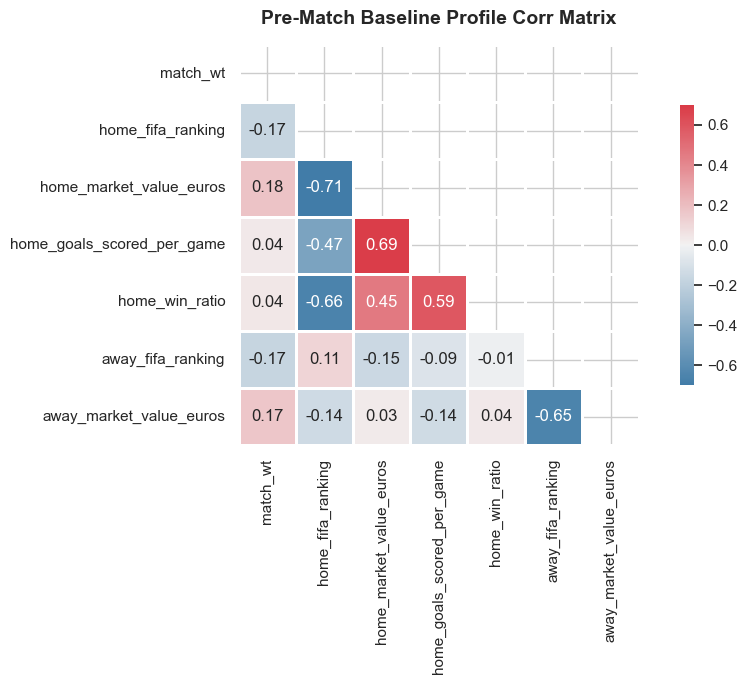

In [53]:
eda_cols = [ 'match_wt', 'home_fifa_ranking', 'home_market_value_euros', 'home_goals_scored_per_game', 'home_win_ratio', 'away_fifa_ranking', 'away_market_value_euros' ]
plt.figure(figsize=(10,7))
corr_matrix = df_final_features[eda_cols].corr()
triangle_mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=triangle_mask,
    cmap=sns.diverging_palette(240, 10, as_cmap=True),
    vmax=.7, vmin=-.7, center=0,
    square=True, linewidths=.8,
    cbar_kws={"shrink": .7},
    annot=True, fmt=".2f"
)
plt.title("Pre-Match Baseline Profile Corr Matrix", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [54]:
split_date = pd.to_datetime('2021-01-01')
df_train = df_final_features[df_final_features['date'] < split_date].copy()
df_test = df_final_features[df_final_features['date'] >= split_date].copy()
for df in [df_train, df_test]:
    df['home_power_score'] = np.exp(-df['home_fifa_ranking'] / 20.0)
    df['away_power_score'] = np.exp(-df['away_fifa_ranking'] / 20.0)
    
    

    df['market_value_ratio'] = (
        df['home_market_value_euros'] /
        np.maximum(df['away_market_value_euros'], 1)
    )
    df['win_ratio_delta'] = df['home_win_ratio'] - df['away_win_ratio']

    df['scoring_delta'] = (
    df['home_goals_scored_per_game'] - df['away_goals_conceded_per_game']
)
    
    df['defensive_delta'] = (
    df['home_goals_conceded_per_game'] - df['away_goals_scored_per_game']
)
    

    df['goal_diff_abs'] = np.abs(df['home_goals_scored_per_game'] - df['away_goals_scored_per_game'])

    

    df['market_gap'] = np.abs(np.log1p(df['home_market_value_euros']) - np.log1p(df['away_market_value_euros']))
    df['elo_diff_abs'] = np.abs(df['elo_diff'])
    df['elo_balance'] = np.exp(-df['elo_diff_abs'] / 300)
    df['elo_tightness'] = np.exp(-np.abs(df['elo_diff']) / 350)
    df['strength_asymmetry'] = np.abs(df['win_ratio_delta']) * np.abs(df['elo_diff'])


    


    
    
    
outcome_mapping = {'H' : 0, 'D': 1, 'A' : 2}
y_train = df_train['outcome'].map(outcome_mapping)
y_test = df_test['outcome'].map(outcome_mapping)

y_train = tf.keras.utils.to_categorical(y_train, 3)
y_test = tf.keras.utils.to_categorical(y_test, 3)

feature_columns = [
    'match_wt',
    'neutral_flag',
    'elo_diff',
    'elo_balance',
    'win_ratio_delta',
    'home_host_indicator',
    'away_host_indicator',
    'elo_tightness',
    'strength_asymmetry',
    'market_gap'
]
#Decisive matches only (STAGE 1)
df_train_s1 = df_train[df_train['target_draw'] == 0].copy()
df_test_s1 = df_test[df_test['target_draw'] == 0].copy()

X_train_s1 = df_train_s1[feature_columns].astype('float32')
X_test_s1 = df_test_s1[feature_columns].astype('float32')

y_train_s1 = df_train_s1['target_binary'].values.astype('float32')
y_test_s1 = df_test_s1['target_binary'].values.astype('float32')

#ALL matches to inlcude draws
X_train_s2 = df_train[feature_columns].astype('float32')
X_test_s2 = df_test[feature_columns].astype('float32')

y_train_s2 = df_train['target_draw'].values.astype('float32')
y_test_s2 = df_test['target_draw'].values.astype('float32')

pd.reset_option('display.float_format')
scaler_s1 = StandardScaler()
X_train_s1_scaled = scaler_s1.fit_transform(X_train_s1)
X_test_s1_scaled = scaler_s1.transform(X_test_s1)
scaler_s2 = StandardScaler()
X_train_s2_scaled = scaler_s2.fit_transform(X_train_s2)
X_test_s2_scaled = scaler_s2.transform(X_test_s2)
print(f"Stage 1 (Strength) Train Shape: {X_train_s1_scaled.shape}, Targets: {y_train_s1.shape}")
print(f"Stage 2 (Draw) Train Shape: {X_train_s2_scaled.shape}, Targets: {y_train_s2.shape}")



Stage 1 (Strength) Train Shape: (7121, 10), Targets: (7121,)
Stage 2 (Draw) Train Shape: (9402, 10), Targets: (9402,)


In [55]:
from tensorflow.keras.callbacks  import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

print("Starting Stage 1...")
model_s1 = Sequential([
    Dense(96, input_shape=(X_train_s1_scaled.shape[1],), activation='relu'),
    Dropout(.3),
    Dense(48, activation='relu'),
    Dropout(.25),
    Dense(24, activation='relu'),
    Dense(1, activation='sigmoid')
])
model_s1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=.001),
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=.05),
    metrics=['accuracy']
)
weights_s1 = compute_class_weight('balanced', classes=np.unique(y_train_s1), y=y_train_s1)
class_weights_s1 = dict(zip(np.unique(y_train_s1), weights_s1))

early_stop_s1 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
print("Training Stage 1 Model...")
history_s1 = model_s1.fit(
    X_train_s1_scaled,
    y_train_s1,
    epochs=25, 
    batch_size=32,
    validation_split=.2,
    class_weight=class_weights_s1,
    callbacks=[early_stop_s1],
    verbose=1
)
print("-" * 50)

print("Starting Stage 2: Draw Calibration Model...")
model_s2 = Sequential([
    Dense(96, input_shape=(X_train_s2_scaled.shape[1],), activation='relu'),
    Dropout(.3),
    Dense(48, activation='relu'),
    Dropout(.25),
    Dense(24, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_s2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=.001),
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=.05),
    metrics=['accuracy']
)
weights_s2 = compute_class_weight('balanced', classes=np.unique(y_train_s2), y=y_train_s2)
class_weights_s2 = dict(zip(np.unique(y_train_s2), weights_s2))

early_stop_s2 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
print("Training Stage 2 Model...")
history_s2 = model_s2.fit(
    X_train_s2_scaled,
    y_train_s2,
    epochs=25,
    batch_size=32,
    validation_split=.2,
    class_weight=class_weights_s2,
    callbacks=[early_stop_s2],
    verbose=1
)
print("\n Both models training successful")

Starting Stage 1...
Training Stage 1 Model...
Epoch 1/25


c:\Users\yashi\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6573 - loss: 0.5400 - val_accuracy: 0.8239 - val_loss: 0.4110
Epoch 2/25
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7421 - loss: 0.4796 - val_accuracy: 0.8225 - val_loss: 0.4202
Epoch 3/25
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7439 - loss: 0.4763 - val_accuracy: 0.8211 - val_loss: 0.4237
Epoch 4/25
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7623 - loss: 0.4722 - val_accuracy: 0.8161 - val_loss: 0.4233
Epoch 5/25
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7546 - loss: 0.4695 - val_accuracy: 0.8225 - val_loss: 0.4198
Epoch 6/25
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7586 - loss: 0.4649 - val_accuracy: 0.8295 - val_loss: 0.4216
--------------------------------------------------
Starting Stage 2: Draw Calibration Model...
Training Stage 2 Model...


c:\Users\yashi\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25
236/236 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5224 - loss: 0.6875 - val_accuracy: 0.6247 - val_loss: 0.6466
Epoch 2/25
236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5225 - loss: 0.6823 - val_accuracy: 0.5354 - val_loss: 0.6588
Epoch 3/25
236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5025 - loss: 0.6807 - val_accuracy: 0.5779 - val_loss: 0.6377
Epoch 4/25
236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4928 - loss: 0.6789 - val_accuracy: 0.6007 - val_loss: 0.6407
Epoch 5/25
236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4874 - loss: 0.6765 - val_accuracy: 0.5875 - val_loss: 0.6469
Epoch 6/25
236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5178 - loss: 0.6759 - val_accuracy: 0.6167 - val_loss: 0.6268
Epoch 7/25
236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5027 - loss: 0.6776 - val_accuracy: 0.6103 - val_loss: 0.6360
Epoch 8/25
236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5209 - loss: 0.6738 - val_accuracy: 0.

In [56]:
from sklearn.metrics import confusion_matrix, classification_report



p_h_given_decisive = model_s1.predict(X_test_s2_scaled, verbose=0).flatten()
p_draw_raw = model_s2.predict(X_test_s2_scaled, verbose=0).flatten()

draw_sensitivity = .79
p_draw_final = p_draw_raw * draw_sensitivity

p_home_final = (1 - p_draw_final) * p_h_given_decisive
p_away_final = (1 - p_draw_final) * (1 - p_h_given_decisive)

y_pred_probs = np.column_stack((p_home_final, p_draw_final, p_away_final))
y_pred = np.argmax(y_pred_probs, axis=1)

outcome_mapping = {'H': 0, 'D': 1, 'A': 2}
y_true = df_test['outcome'].map(outcome_mapping).values
correct_predictions = (y_pred == y_true).sum()
test_accuracy = correct_predictions / len(y_true)
print(f"Overall 3-Class Test Accuracy: {test_accuracy:.4f}\n")
print("Confusion Matrix: ")
print(confusion_matrix(y_true, y_pred))
print("\n Average Class Probabilities: ")
print(y_pred_probs.mean(axis=0))
print("\n Classification Report: ")
print(classification_report(y_true, y_pred))


Overall 3-Class Test Accuracy: 0.6397

Confusion Matrix: 
[[1241  261   69]
 [ 309  198  104]
 [  61  154  262]]

 Average Class Probabilities: 
[0.47479805 0.33039802 0.19480452]

 Classification Report: 
              precision    recall  f1-score   support

           0       0.77      0.79      0.78      1571
           1       0.32      0.32      0.32       611
           2       0.60      0.55      0.57       477

    accuracy                           0.64      2659
   macro avg       0.57      0.55      0.56      2659
weighted avg       0.64      0.64      0.64      2659



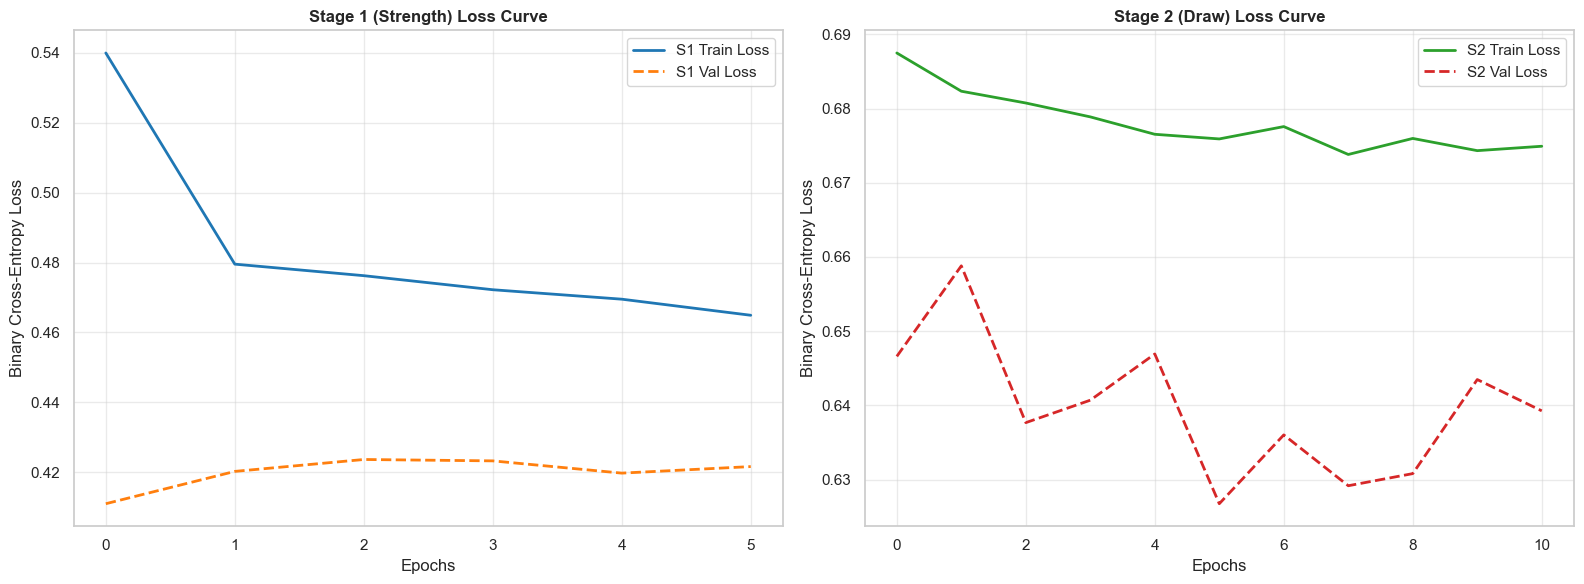

📊 TWO-STAGE DECOUPLED PIPELINE METRICS (Sensitivity: 0.79)
              precision    recall  f1-score   support

Home Win (0)       0.77      0.79      0.78      1571
     Draw(1)       0.32      0.32      0.32       611
Away Win (2)       0.60      0.55      0.57       477

    accuracy                           0.64      2659
   macro avg       0.57      0.55      0.56      2659
weighted avg       0.64      0.64      0.64      2659

Base Training Distribution [Decisive, Draw]: [0.75739204 0.24260796]
Model Test Home Win Prediction Rate:          0.6059
Actual Test Home Win Baseline Distribution:   0.5908
Model Test Draw Prediction Rate:          0.2305
Actual Test Draw Baseline Distribution:   0.2298
Model Test Away Win Prediction Rate:          0.1636
Actual Test Away Win Baseline Distribution:   0.1794


In [57]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))
ax1.plot(history_s1.history['loss'], label='S1 Train Loss', color='#1f77b4', linewidth=2)
ax1.plot(history_s1.history['val_loss'], label='S1 Val Loss', color='#ff7f0e', linewidth=2, linestyle='--')
ax1.set_title('Stage 1 (Strength) Loss Curve', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Binary Cross-Entropy Loss')
ax1.legend()
ax1.grid(True, alpha=.4)

ax2.plot(history_s2.history['loss'], label='S2 Train Loss', color='#2ca02c', linewidth=2)
ax2.plot(history_s2.history['val_loss'], label='S2 Val Loss', color='#d62728', linewidth=2, linestyle='--')
ax2.set_title('Stage 2 (Draw) Loss Curve', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Binary Cross-Entropy Loss')
ax2.legend()
ax2.grid(True, alpha=.4)

plt.tight_layout()
plt.show()

print("=" * 60)
print(f"📊 TWO-STAGE DECOUPLED PIPELINE METRICS (Sensitivity: {draw_sensitivity})")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=['Home Win (0)', 'Draw(1)', 'Away Win (2)']))
train_draw_dist = np.bincount(y_train_s2.astype(int)) / len(y_train_s2)
print(f"Base Training Distribution [Decisive, Draw]: {train_draw_dist}")
print(f"Model Test Home Win Prediction Rate:          {np.mean(y_pred == 0):.4f}")
print(f"Actual Test Home Win Baseline Distribution:   {np.mean(y_true == 0):.4f}")
print(f"Model Test Draw Prediction Rate:          {np.mean(y_pred == 1):.4f}")
print(f"Actual Test Draw Baseline Distribution:   {np.mean(y_true == 1):.4f}")
print(f"Model Test Away Win Prediction Rate:          {np.mean(y_pred == 2):.4f}")
print(f"Actual Test Away Win Baseline Distribution:   {np.mean(y_true == 2):.4f}")
print("=" * 60)
 

In [58]:
df_26 = pd.read_csv('world_cup_26_games.csv')

df_26.rename(columns={'ESPN_ID' : 'espn_id'}, inplace=True)
df_26['neutral_flag'] = df_26['neutral_flag'].astype(float)

df_home_profiles = df_master_profiles.add_prefix('home_')
df_away_profiles = df_master_profiles.add_prefix('away_')

def run_two_stage_inference(df_pass_features):
    X_s1_scaled = scaler_s1.transform(df_pass_features[feature_columns])
    X_s2_scaled = scaler_s2.transform(df_pass_features[feature_columns])

    p_h_given_decisive = model_s1.predict(X_s1_scaled, verbose=0).flatten()
    p_draw_raw = model_s2.predict(X_s2_scaled, verbose=0).flatten()

    draw_sensitivity = .79
    p_draw_final = p_draw_raw * draw_sensitivity

    p_home_final = (1 - p_draw_final) * p_h_given_decisive
    p_away_final = (1 - p_draw_final) * (1 - p_h_given_decisive)
    return np.column_stack((p_home_final, p_draw_final, p_away_final))


df_pass1 = df_26.merge(df_home_profiles, left_on='home_team', right_on='home_Squad', how='left')
df_pass1 = df_pass1.merge(df_away_profiles, left_on='away_team', right_on='away_Squad', how='left')
df_pass1['match_wt'] = 4
df_pass1['neutral_flag'] = 1
df_pass1['home_host_indicator'] = 0 
df_pass1['away_host_indicator'] = 0
df_pass1.fillna(fill_baselines, inplace=True)

df_pass1['home_elo_mapped'] = df_pass1['home_team'].map(elo_dict).fillna(1500.0)
df_pass1['away_elo_mapped'] = df_pass1['away_team'].map(elo_dict).fillna(1500.0)
df_pass1['elo_diff'] = df_pass1['home_elo_mapped'] - df_pass1['away_elo_mapped']

df_pass1['win_ratio_delta'] = df_pass1['home_win_ratio'] - df_pass1['away_win_ratio']
df_pass1['elo_diff_abs'] = np.abs(df_pass1['elo_diff'])
df_pass1['elo_balance'] = np.exp(-df_pass1['elo_diff_abs'] / 300)
df_pass1['elo_tightness'] = np.exp(-np.abs(df_pass1['elo_diff']) / 350)
df_pass1['strength_asymmetry'] = np.abs(df_pass1['win_ratio_delta']) * np.abs(df_pass1['elo_diff'])
df_pass1['market_gap'] = np.abs(np.log1p(df_pass1['home_market_value_euros']) - np.log1p(df_pass1['away_market_value_euros']))
preds_pass1 = run_two_stage_inference(df_pass1)
df_swapped = df_26.copy()
df_swapped['home_team'] = df_26['away_team']
df_swapped['away_team'] = df_26['home_team']

df_pass2 = df_swapped.merge(df_home_profiles, left_on='home_team', right_on='home_Squad', how='left')
df_pass2 = df_pass2.merge(df_away_profiles, left_on='away_team', right_on='away_Squad', how='left')
df_pass2['match_wt'] = 4
df_pass2['neutral_flag'] = 1
df_pass2['home_host_indicator'] = 0 
df_pass2['away_host_indicator'] = 0
df_pass2.fillna(fill_baselines, inplace=True)

df_pass2['home_elo_mapped'] = df_pass2['home_team'].map(elo_dict).fillna(1500.0)
df_pass2['away_elo_mapped'] = df_pass2['away_team'].map(elo_dict).fillna(1500.0)
df_pass2['elo_diff'] = df_pass2['home_elo_mapped'] - df_pass2['away_elo_mapped']

df_pass2['win_ratio_delta'] = df_pass2['home_win_ratio'] - df_pass2['away_win_ratio']
df_pass2['elo_diff_abs'] = np.abs(df_pass2['elo_diff'])
df_pass2['elo_balance'] = np.exp(-df_pass2['elo_diff_abs'] / 300)
df_pass2['elo_tightness'] = np.exp(-np.abs(df_pass2['elo_diff']) / 350)
df_pass2['strength_asymmetry'] = np.abs(df_pass2['win_ratio_delta']) * np.abs(df_pass2['elo_diff'])
df_pass2['market_gap'] = np.abs(np.log1p(df_pass2['home_market_value_euros']) - np.log1p(df_pass2['away_market_value_euros']))
preds_pass2 = run_two_stage_inference(df_pass2)

avg_h_win = (preds_pass1[:, 0] + preds_pass2[:, 2]) / 2
avg_draw = (preds_pass1[:, 1] + preds_pass2[:, 1]) / 2
avg_a_win = (preds_pass1[:, 2] + preds_pass2[:, 0]) / 2

totals = avg_h_win + avg_draw + avg_a_win
final_h_pct = (avg_h_win / totals) * 100
final_draw_pct = (avg_draw / totals) * 100
final_a_pct = (avg_a_win / totals) * 100

df_26_baselines = pd.DataFrame({
    'Match_ID': df_26['match_id'].values,
    'Stage': df_26['stage'].values,
    'Home Team': df_26['home_team'].values,
    'Away Team': df_26['away_team'].values,
    'ESPN_ID': df_26['espn_id'].values,
    'Pre_Home_Win_Pct': final_h_pct.round(2),
    'Pre_Draw_Pct': final_draw_pct.round(2),
    'Pre_Away_Win_Pct': final_a_pct.round(2),
})
placeholder_mask = df_26_baselines['Home Team'].str.contains('Winner|Loser|Place|Third', case=False, na=False)
df_26_baselines.loc[placeholder_mask, 'Pre_Home_Win_Pct'] = 37.50
df_26_baselines.loc[placeholder_mask, 'Pre_Draw_Pct'] = 25.00
df_26_baselines.loc[placeholder_mask, 'Pre_Away_Win_Pct'] = 37.50

df_26_baselines.to_csv('world_cup_26_baselines.csv', index=False)
print("Baselines compted through two stage model and csv created")
df_26_baselines.sample(5)

Baselines compted through two stage model and csv created


,Match_ID,Stage,Home Team,Away Team,ESPN_ID,Pre_Home_Win_Pct,Pre_Draw_Pct,Pre_Away_Win_Pct
74,75,Round of 32,Group E Winner,Third Place Group A/B/C/D/F,760489,37.500000,25.000000,37.500000
64,65,Group G,Egypt,Iran,760476,29.910000,40.139999,29.940001
3,4,Group D,United States,Paraguay,760417,29.340000,40.299999,30.350000
87,88,Round of 32,Group K Winner,Third Place Group D/E/I/J/L,760501,37.500000,25.000000,37.500000
13,14,Group G,Belgium,Egypt,760426,31.459999,40.060001,28.480000


In [59]:
##Evaluation Cell
from sklearn.metrics import log_loss

def eval_live_preds(preds_csv_path, results_df):
    df_preds = pd.read_csv(preds_csv_path)
    df_eval = df_preds.merge(results_df, left_on='Match_ID', right_on='match_id')
    
    if df_eval.empty:
        print("No completed games found to evaluate yet.")
        return
    
    P = df_eval[['Pre_Home_Win_Pct', 'Pre_Draw_Pct', 'Pre_Away_Win_Pct']].values / 100

    outcome_mapping = {'H': 0, 'D': 1, 'A': 2}
    y_true = df_eval['actual_outcome'].map(outcome_mapping).values
    O = np.zeros_like(P)
    O[np.arange(len(y_true)),y_true] = 1
    brier_score = np.mean(np.sum((P-O) ** 2, axis=1))
    current_log_loss = log_loss(y_true, P, labels=[0, 1, 2])
    y_pred = np.argmax(P, axis=1)
    accuracy = np.mean(y_pred == y_true)

    print("=" * 50)
    print(f"🏆 LIVE WORLD CUP MODEL PERFORMANCE ({len(df_eval)} Games Evaluated)")
    print("=" * 50)
    print(f"Accuracy (Highest Prob): {accuracy * 100:.2f}%")
    print(f"Brier Score:              {brier_score:.4f}  (Lower is better, target < 0.55)")
    print(f"Log Loss:                 {current_log_loss:.4f}")
    print("=" * 50)

results_test = pd.DataFrame({
    'match_id': [1,2],
    'actual_outcome': ['D', 'H']
})
eval_live_preds('world_cup_26_baselines.csv', results_test)


🏆 LIVE WORLD CUP MODEL PERFORMANCE (2 Games Evaluated)
Accuracy (Highest Prob): 100.00%
Brier Score:              0.5592  (Lower is better, target < 0.55)
Log Loss:                 0.9412
